# Sleep Profiler EEG Analysis Test


This notebook is to workshop how to import EDF files into Python for subsequent autostaging and sleep microarchitecture analysis.


In [1]:
## load dependencies
## Not all of these are necessarily required for EEG analysis, (sns, plt) but I like to load a set of standard Python libraries just in case I'll end up using them later on and don't want to import packages in seemingly random places.
import pandas as pd
import numpy as np
import mne
import yasa
import sleepeegpy
from matplotlib import pyplot as plt
import seaborn as sns
import os

## Import EEG.edf file(s)

In [2]:
## Establish where EEG files are stored for retrieval
file_path = []

In [3]:
## import EEG.edf file and hypnogram (csv)
raw = mne.io.read_raw_edf('KellyS_Test.edf',
                          infer_types= True, ## tries to automatically understand what channel is which based on name
                           preload=True) 

## preload (default = False) preloads data into memory for faster indexing (requires large amount of memory) and may not be required but is recommended in later method below.

## mne.io.raw documentation recommends preload = True, otherwise edge artifacts appear when slices of the dignal are requested. 

Extracting EDF parameters from /Users/thomasgooding/Desktop/Git_mats/Portfolio/Data_Projects/Rutgers Research/Sleep_Profiler_SOP/KellyS_Test.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6918399  =      0.000 ... 27024.996 secs...


In [4]:
print(raw)

<RawEDF | KellyS_Test.edf, 26 x 6918400 (27025.0 s), ~1.34 GB, data loaded>


In [5]:
raw.info ## this is considered an attribute (vs. a method)

# attributes = static properties of Python objects- things that are pre-computed and stored as part of the object's representation in memory. Attributes are accessed with the . operator and don't require parentheses after the attribute name

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,26 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [6]:
## get channel names, another attribute
raw.ch_names

['EEG1',
 'EEG2',
 'EEG3',
 'EEG4',
 'Tilt1',
 'Tilt2',
 'Tilt3',
 'IRED',
 'RED',
 'Snore',
 'TC0',
 'TC1',
 'TC2',
 'TC3',
 'TC4',
 'TC5',
 'TC6',
 'TC7',
 'TC8',
 'TC9',
 'TC10',
 'TC11',
 'TC12',
 'TC13',
 'TC14',
 'TC15']

In [7]:
## drop channels TC0 to TC15. These are internal to the X8 device and not phyisological signal (may learn otherwise later)
raw.drop_channels([f'TC{i}' for i in range(16)]) # this is considered a Python method ()

## methods are specialized functions attached to an object. Usually, these require additional user input (kwargs) and/or some computation to provide a result. These always have () at the end and additional arguments go inside the 


Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,10 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [8]:
## set channel types for mapping
channel_types = {
    'EEG1':'eeg', 'EEG2':'eeg', 'EEG3':'eeg', 'EEG4':'eeg', 'Tilt1': 'misc', 'Tilt2':'misc',
    'Tilt3':'misc', 'IRED':'bio', 'RED':'bio', 'Snore':'misc'}

raw.set_channel_types(channel_types)
## this works even though the output is a dropdown (note the Good channel types) compared to the previous window

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_49757/2618792468.py:6: RuntimeWarning: The unit for channel(s) Snore, Tilt1, Tilt2, Tilt3 has changed from V to NA.
  raw.set_channel_types(channel_types)


Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"4 EEG, 4 misc, 2 BIO"
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [9]:
print(raw.get_channel_types())

['eeg', 'eeg', 'eeg', 'eeg', 'misc', 'misc', 'misc', 'bio', 'bio', 'misc']


In [10]:
## time_as_index converts a time (s) into the integer index of the sample occurring closest to that time. 
## don't think this is needed 

# raw.time_as_index(30)

In [11]:
len(raw) #length of y-axis (axis 1)

6918400

Effective window size : 8.000 (s)


/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_49757/192296578.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=50).plot(picks='data', exclude='bads', amplitude=False)
/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne/viz/utils.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


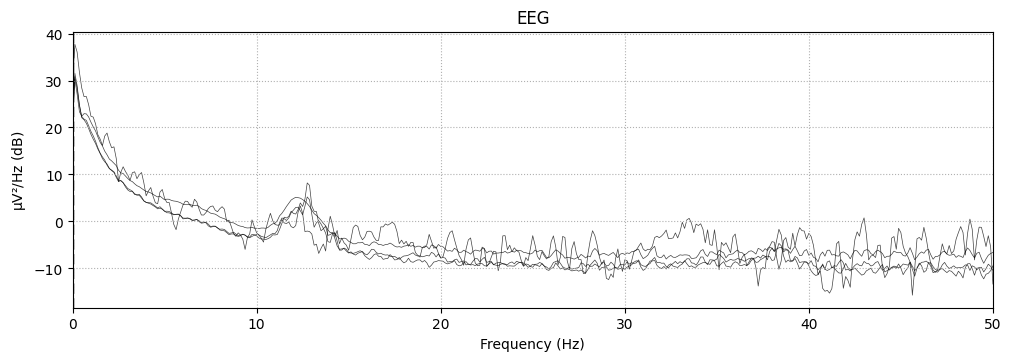

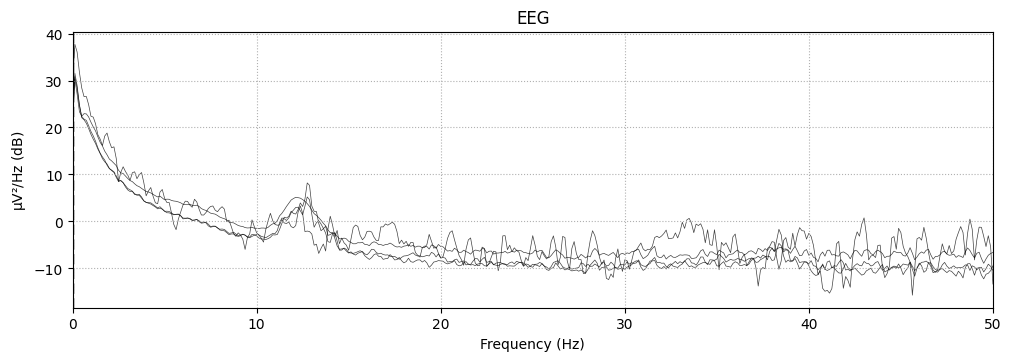

In [12]:
raw.compute_psd(fmax=50).plot(picks='data', exclude='bads', amplitude=False)


## Import hypnogram

In [13]:
## import hypnogram
hypno = pd.read_csv('KellyS_epoch_data.csv')

hypno.head()

,Subject #,Epoch #,Night,StudyDate,ElapsedTime,ElapsedTime(sec),ClockTime,PrimaryAutoStage,SecondaryAutoStage,TechEditStage,Stage final,ChannelStaged,ImpLEOG,ImpREOG,ImpEEG
0,421000303,1,1,13-Feb-25,0:00:31,31,1:02:22,0,0,NaN,0,EEG,4,2,6
1,421000303,2,1,13-Feb-25,0:01:01,61,1:02:52,0,0,NaN,0,EEG,4,2,6
2,421000303,3,1,13-Feb-25,0:01:31,91,1:03:22,0,0,NaN,0,EEG,4,2,6
3,421000303,4,1,13-Feb-25,0:02:01,121,1:03:52,0,0,NaN,0,EEG,4,2,6
4,421000303,5,1,13-Feb-25,0:02:31,151,1:04:22,0,0,NaN,0,EEG,4,2,6


In [14]:
hypno.describe()

## count = 899 of 30 second epochs = 449.5 minutes

,Subject #,Epoch #,Night,ElapsedTime(sec),PrimaryAutoStage,SecondaryAutoStage,TechEditStage,Stage final,ImpLEOG,ImpREOG,ImpEEG
count,899.0,899.000000,899.0,899.000000,899.000000,899.000000,0.0,899.000000,899.000000,899.000000,899.000000
mean,421000303.0,450.000000,1.0,13501.000000,2.652948,2.598443,NaN,2.652948,1.529477,26.291435,35.028921
std,0.0,259.663243,0.0,7789.897304,1.344675,1.372672,NaN,1.344675,0.760940,75.325483,85.211653
min,421000303.0,1.000000,1.0,31.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,421000303.0,225.500000,1.0,6766.000000,2.000000,2.000000,NaN,2.000000,1.000000,1.000000,1.000000
50%,421000303.0,450.000000,1.0,13501.000000,2.000000,2.000000,NaN,2.000000,1.000000,1.000000,1.000000
75%,421000303.0,674.500000,1.0,20236.000000,3.000000,3.000000,NaN,3.000000,2.000000,2.000000,2.000000
max,421000303.0,899.000000,1.0,26971.000000,5.000000,5.000000,NaN,5.000000,4.000000,252.000000,252.000000


In [15]:
hypno.columns = hypno.columns.str.lower().str.replace(' ', '_')

hypno.columns

Index(['subject_#', 'epoch_#', 'night', 'studydate', 'elapsedtime',
       'elapsedtime(sec)', 'clocktime', 'primaryautostage',
       'secondaryautostage', 'techeditstage', 'stage_final', 'channelstaged',
       'impleog', 'impreog', 'impeeg'],
      dtype='object')

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_49757/3677501710.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stage_labels.values())


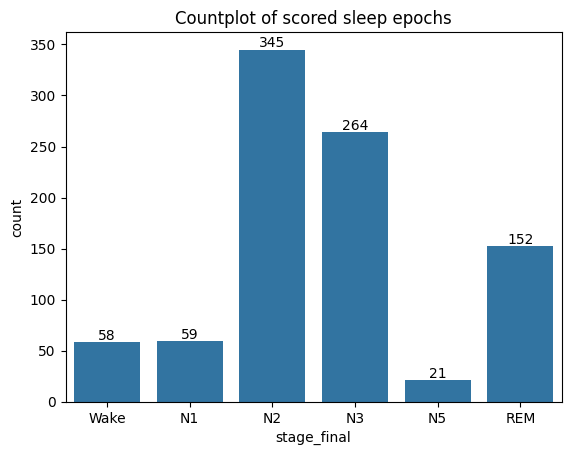

In [16]:
ax = sns.countplot(data= hypno, x='stage_final')
ax.bar_label(ax.containers[0], label_type = 'edge')

## labels based on SleepProfiler documentation
stage_labels = {
    0 : 'Wake',
    1 : 'N1',
    2 : 'N2',
    3 : 'N3', 
    4 : 'N5',
    5 : 'REM'
}

ax.set_xticklabels(stage_labels.values())
ax.set_title('Countplot of scored sleep epochs')
plt.show()

## 899 total count (30s) = 449.5 min

In [17]:
## set channel types for mapping
channel_types = {
    'EEG1':'eeg', 'EEG2':'eeg', 'EEG3':'eeg', 'EEG4':'eeg', 'Tilt1': 'misc', 'Tilt2':'misc',
    'Tilt3':'misc', 'IRED':'bio', 'RED':'bio', 'Snore':'misc'}

raw.set_channel_types(channel_types)

## this works even though the output is a dropdown (note the Good channel types) compared to the previous window

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"4 EEG, 4 misc, 2 BIO"
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [18]:
raw.n_times
## 6918400 timepoints

6918400

In [19]:
print(raw.get_channel_types())

['eeg', 'eeg', 'eeg', 'eeg', 'misc', 'misc', 'misc', 'bio', 'bio', 'misc']


### MNE Raw methods and attributes for potential use:

- raw.crop() can isolate a window of time (seconds) including start/stop as arguments.
- raw.rename_channels()
- raw.drop_channels()
- raw.get_data() for if you want the data and not the corresponding array of times
- 

### Spectrum and EpochsSpectrum classes: frequency-domain data

source: 
https://mne.tools/stable/auto_tutorials/time-freq/10_spectrum_class.html

In [20]:
### MNE Preprocessing documentation

https://mne.tools/stable/api/preprocessing.html

- MNE preprocessing Independent Component Analysis (ICA) available but lengthy documentation

SyntaxError: invalid syntax (3210057867.py, line 3)

## Use YASA to remove artifact

In [ ]:
from collections import Counter
Counter(hypno['stage_final'])

## shows how many instances there are of each unique value in this array/colum.

Counter({2: 345, 3: 264, 5: 152, 1: 59, 0: 58, 4: 21})

In [ ]:
## map hypnogram stages based on SleepProfiler stage scoring documentation
stage_map = {
    0 : 'WAKE',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'N2', ## Light N2 (Still N2)
    5: 'REM', 
    6: 'UNS', ## sleep not otherwise specified
    9: 'UNS', ## artifact/ INVALID
    14: 'N2',
    33: 'N3', ## atypical N3, mapped to N3
    55: 'REM' ## REM without atonia, mapped to REM
}

hypno_sorted = hypno.sort_values('epoch_#').copy()
hypno_sorted['yasa_stage'] = hypno_sorted['stage_final'].map(stage_map)

# Check nothing fell through unmapped
print(hypno_sorted["yasa_stage"].isna().sum(), "unmapped epochs")

stage_sequence = hypno_sorted["yasa_stage"].values
hyp = yasa.Hypnogram(stage_sequence, freq="30s")

0 unmapped epochs


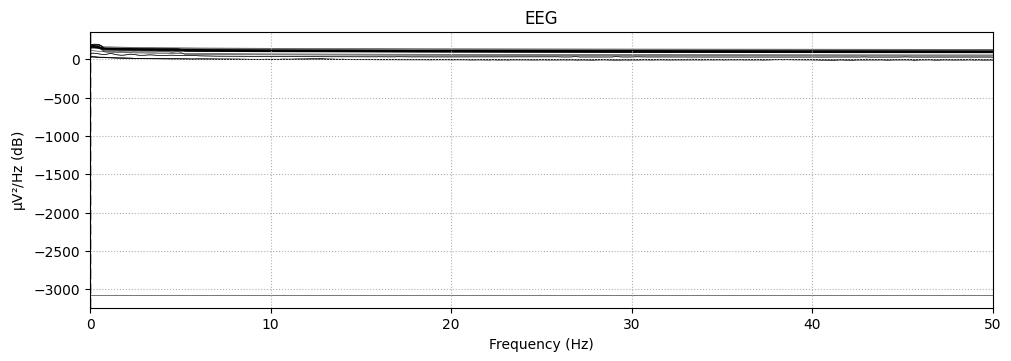

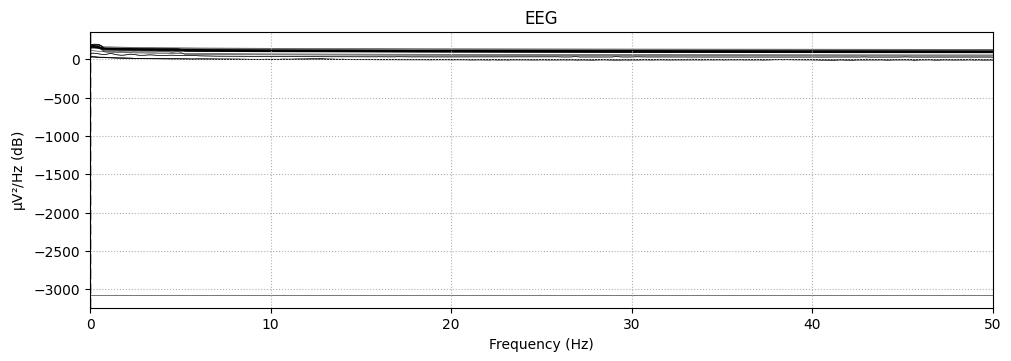

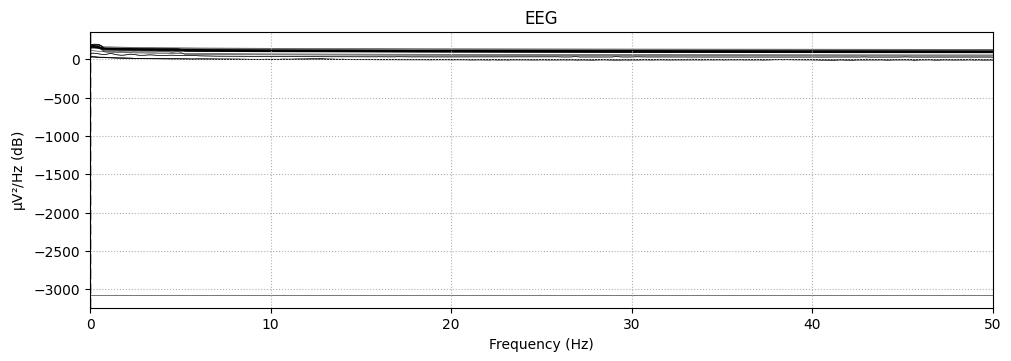

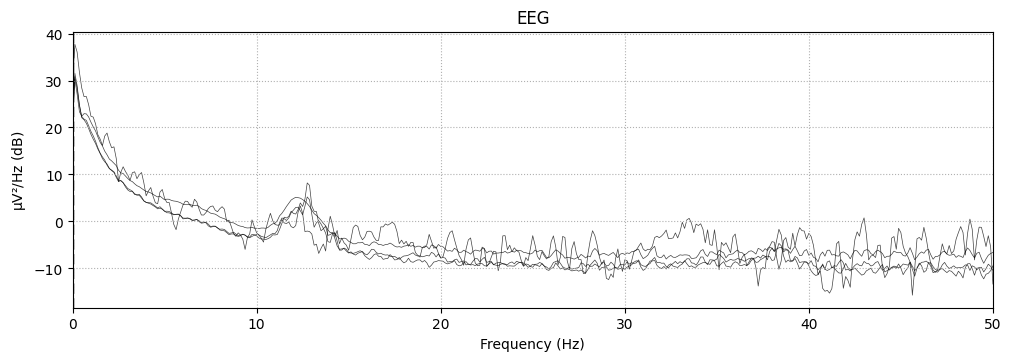

/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne_qt_browser/_pg_figure.py:167: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  data_chunk, times_chunk = browser._load_data(start, stop)


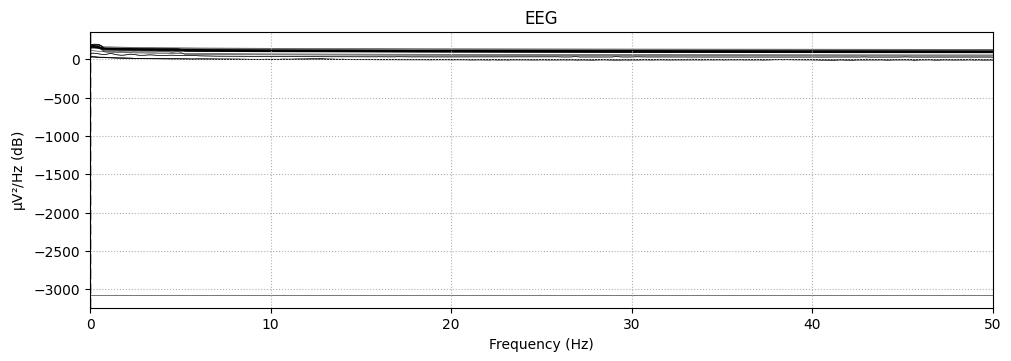

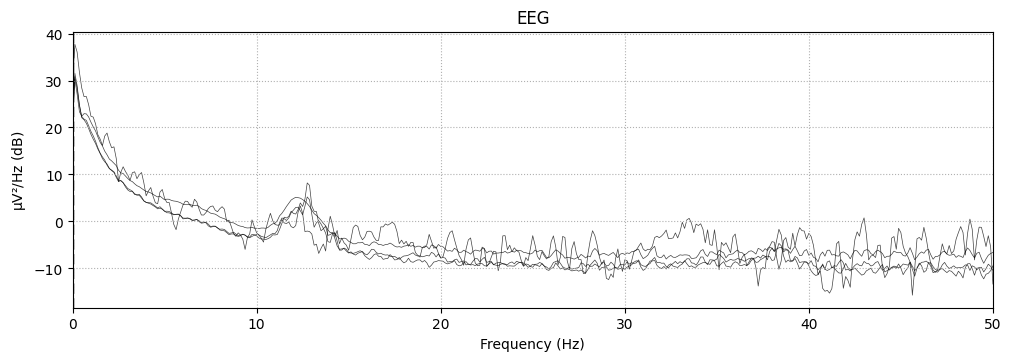

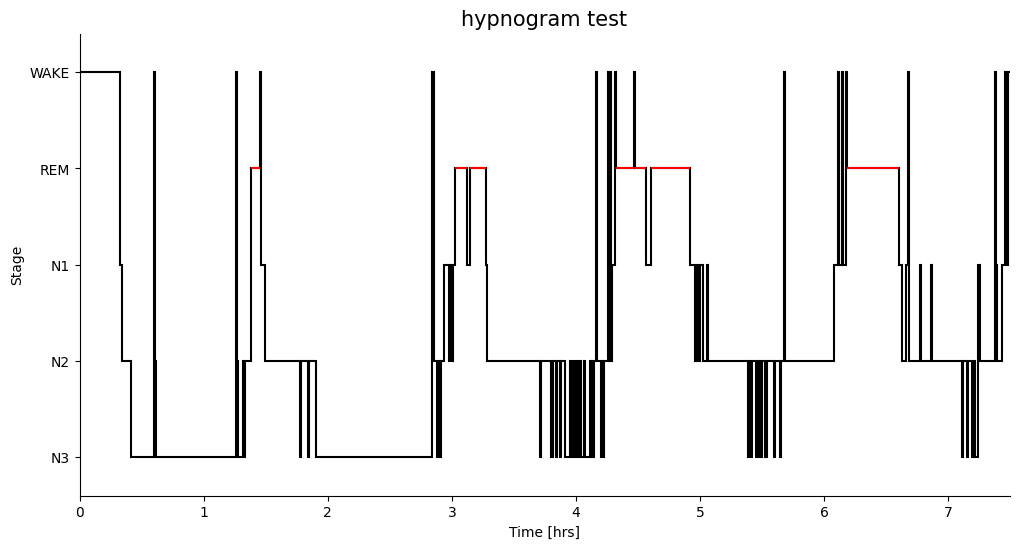

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

ax = hyp.plot_hypnogram()

plt.title('hypnogram test', fontsize=15)
plt.show()

In [ ]:
449.5 /60

7.491666666666666

## Basic sleep statistics

In [ ]:
7.55*60

453.0

Below are the following variables reported from running hypnogram.sleep_statistics. Results from the test_files (KellyS) are reported below each variable with SP indicating the SleepProfiler equivalent.

- **Time in Bed (TIB):** total duration (min) of the hypnogram.
  - 449.5 min
  - SP recording time(study time) = 8.07 h (484.2 min) 
  - **Note:** hypnogram.sleep_statistics automatically excluded epochs listed as 'artifact' or 'unscored.'

- **Sleep Period Time (SPT):** duration (min) from first to last period of sleep.
  - 429.5
- **Wake After Sleep Onset (WASO):** duration of wake periods within SPT.
  - 9.0
- **Total Sleep Time (TST):** total sleep duration in SPT. calculated as the sum of all REM and NREM sleep in SPT
  - 420.5
  - 453 (SP 7.55 h)
- **Sleep Onset Latency (SOL):** Latency to first epoch of any sleep.
  - 19.5
  - 15 (SP)
- **SOL 5min:** Latency to 5 minutes of persistent sleep (any stage).
  - 19.5
- **REM latency:** latency to first REM sleep.
  - 83.0
- **Sleep Efficiency (SE):** TST / TIB * 100 (%).
  - 93.55%
- **Sleep Maintenance Efficiency (SME):** TST / SPT * 100 (%).
  - 97.91%
- **Sleep Fragmentation Index:** number of transitions from sleep to wake / hours of TST
- 1.21
- **Sleep stages amount and proportion of TST**
  - WAKE
    - 29
    - 31.2 SP(0.52h)
  - REM 
    - 76
    - 54 SP(0.90h)
  - N1
    - 29.5
    - 54 SP(0.9h)
  - N2
    - 183
    - 199.8 SP(3.33h)
  - N3
    - 132
    - 145.2 SP(2.42h)
  

In [ ]:
hyp.sleep_statistics()

## checking these values out vs. what Sleep Profiler (SP) reports from their autostaging algorithm (intial output)

## in SP, sleep_onset (first 30-s sleep epoch) is at 0:14:43 from beginning of study period (SOL/SOL_5min in this output says 19.5, so 5-min offset?).

##SP study period was 8.1 hours (486 min) with 0 minutes of excluded time, TST = 7.6 hours (456 min). 

## study_start time_date = 07:26:00 on 2/10/2025
## end_time = 15:29:59
## total study time (recording time) = 8.07 h
## sleep time = 7.55 h
## Sleep efficiency = 93.6%
## Wake = 6.4% (0.52 h)
## Stage R = 11.9% (0.9h)
## N1 = 11.9% (0.9h)
## N2 = 44.2% (3.33h)
## N3 = 32% (2.42h)
## Sleep latency = 15min
## WASO = 16min
## N3 latency = 2min
## REM latency = 102min
#### Sleep Continuity metrics ######
## cortical arousals/hr = 7.7
## microarousals/hr- other = 2.0
## awakenings/hr ≥30seconds = 2.3
## awakenings/hr ≥90s = 0.4
## movement arousals/hr = 2.0
## spindle duration (min) = 25.28 min

{'TIB': 449.5,
 'SPT': 429.5,
 'WASO': 9.0,
 'TST': 420.5,
 'SE': 93.5484,
 'SME': 97.9045,
 'SFI': 1.2128,
 'SOL': 19.5,
 'SOL_5min': 19.5,
 'Lat_REM': 83.0,
 'WAKE': 29.0,
 'N1': 29.5,
 'N2': 183.0,
 'N3': 132.0,
 'REM': 76.0,
 '%N1': 7.0155,
 '%N2': 43.5196,
 '%N3': 31.3912,
 '%REM': 18.0737}

In [ ]:
round((429.5/449.5)*100, 2)

95.55

In [ ]:
counts, probs = hyp.transition_matrix()

## counts = number of transitions from stage A to B. pre-transition states are the rows and the post-transition states are the columns
display(counts)

## conditional probability transition matrix, i.e., given that current state is A, what is the probability that the next state is B. Stochastic matrix
display(probs.round(3))

To Stage,WAKE,N1,N2,N3,REM
From Stage,,,,,
WAKE,40,6,8,0,3
N1,7,35,14,0,3
N2,5,12,313,35,1
N3,3,1,31,229,0
REM,2,5,0,0,145


To Stage,WAKE,N1,N2,N3,REM
From Stage,,,,,
WAKE,0.702,0.105,0.140,0.000,0.053
N1,0.119,0.593,0.237,0.000,0.051
N2,0.014,0.033,0.855,0.096,0.003
N3,0.011,0.004,0.117,0.867,0.000
REM,0.013,0.033,0.000,0.000,0.954


In [ ]:
## the stability of sleep can be calculated by taking the average of the diagonal values of N2, N3, and REM sleep

np.diag(probs.loc['N2':, "N2":]).mean().round(3)

0.892

In [ ]:
data_chan = raw.get_data(picks='EEG1')[0]

sf = raw.info['sfreq']

04-Aug-26 09:48:45 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne_qt_browser/_pg_figure.py:167: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  data_chunk, times_chunk = browser._load_data(start, stop)
/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne_qt_browser/_pg_figure.py:167: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  data_chunk, times_chunk = browser._load_data(start, stop)


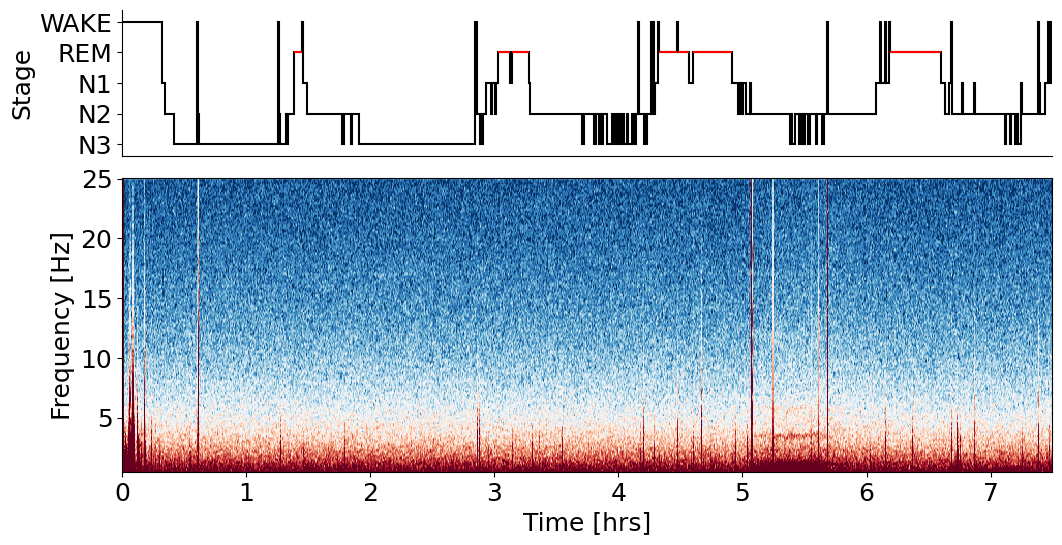

In [ ]:
yasa.plot_spectrogram(data_chan, sf, hyp)

In [ ]:
## EEG power in specific frequency bands
## default is that this is in relative power across all channels
yasa.bandpower(raw)

/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne_qt_browser/_pg_figure.py:167: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  data_chunk, times_chunk = browser._load_data(start, stop)
/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne_qt_browser/_pg_figure.py:167: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  data_chunk, times_chunk = browser._load_data(start, stop)
/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne_qt_browser/_pg_figure.py:167: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.

,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Chan,,,,,,,,,
EEG1,0.862323,0.069138,0.024501,0.013201,0.022314,0.008523,8.651418,0.25,True
EEG2,0.814777,0.096311,0.037733,0.024997,0.020792,0.005390,24.223728,0.25,True
EEG3,0.791590,0.104452,0.043975,0.029124,0.024477,0.006382,21.503423,0.25,True
EEG4,0.773219,0.116793,0.046958,0.033028,0.025094,0.004910,43.406059,0.25,True
Tilt1,0.773101,0.226861,0.000022,0.000007,0.000007,0.000002,35.602820,0.25,True
Tilt2,0.643184,0.356770,0.000026,0.000010,0.000009,0.000002,33.123317,0.25,True
Tilt3,0.751290,0.248679,0.000017,0.000006,0.000006,0.000002,27.493463,0.25,True
IRED,0.988882,0.008582,0.000758,0.000286,0.000941,0.000551,0.000009,0.25,True
RED,0.988882,0.008582,0.000758,0.000286,0.000941,0.000551,0.000009,0.25,True


In [ ]:
## EEG power in specific frequency bands
## here is the absolute power across all channels
## yuck to look at
yasa.bandpower(raw, relative=False)

,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Chan,,,,,,,,,
EEG1,7.460316,5.981405e-01,2.119714e-01,1.142063e-01,1.930438e-01,7.373996e-02,8.651418,0.25,False
EEG2,19.736933,2.333014e+00,9.140319e-01,6.055315e-01,5.036560e-01,1.305623e-01,24.223728,0.25,False
EEG3,17.021894,2.246066e+00,9.456187e-01,6.262600e-01,5.263462e-01,1.372379e-01,21.503423,0.25,False
EEG4,33.562370,5.069504e+00,2.038243e+00,1.433623e+00,1.089211e+00,2.131082e-01,43.406059,0.25,False
Tilt1,27.524576,8.076886e+00,7.740423e-04,2.662930e-04,2.554310e-04,6.221441e-05,35.602820,0.25,False
Tilt2,21.304384,1.181739e+01,8.582870e-04,3.189429e-04,2.942648e-04,6.759097e-05,33.123317,0.25,False
Tilt3,20.655571,6.837045e+00,4.757226e-04,1.518435e-04,1.727112e-04,4.712207e-05,27.493463,0.25,False
IRED,0.000009,7.537948e-08,6.658274e-09,2.513653e-09,8.262743e-09,4.837703e-09,0.000009,0.25,False
RED,0.000009,7.537948e-08,6.658274e-09,2.513653e-09,8.262743e-09,4.837703e-09,0.000009,0.25,False


In [ ]:
## can also pass a hypnogram to calculate the spectral powers separately for each sleep stage. In the example belo,w we pass hypnogram object directly and use string stage labels for include. then, save the results in a new variable named 'bandpower'

bandpower = yasa.bandpower(raw, hypno = hyp, include=['N2', 'N3', 'REM'])

bandpower

04-Aug-26 09:48:53 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Delta     Theta     Alpha     Sigma      Beta     Gamma  \
Stage Chan                                                                
2     EEG1   0.877149  0.061800  0.022122  0.011669  0.019754  0.007506   
      EEG2   0.758818  0.103790  0.057123  0.050626  0.024263  0.005380   
      EEG3   0.732061  0.107938  0.066337  0.057893  0.029092  0.006678   
      EEG4   0.710564  0.121066  0.068695  0.063850  0.030283  0.005542   
      Tilt1  0.750963  0.248999  0.000022  0.000007  0.000007  0.000002   
      Tilt2  0.679417  0.320542  0.000024  0.000008  0.000007  0.000002   
      Tilt3  0.749757  0.250212  0.000017  0.000006  0.000006  0.000002   
      IRED   0.988617  0.008899  0.000836  0.000283  0.000871  0.000494   
      RED    0.988617  0.008899  0.000836  0.000283  0.000871  0.000494   
      Snore  0.812521  0.187441  0.000019  0.000007  0.000010  0.000003   
3     EEG1   0.850657  0.074710  0.026489  0.014270  0.024505  0.009369   
      EEG2   0.933051  0.043055  0.013677  0.006535  0.002673  0.001009   
      EEG3   0.926660  0.045438  0.015794  0.007917  0.003103  0.001087   
      EEG4   0.923541  0.049839  0.014855  0.008527  0.002712  0.000527   
      Tilt1  0.787984  0.211981  0.000020  0.000006  0.000006  0.000002   
      Tilt2  0.568870  0.431090  0.000024  0.000008  0.000007  0.000002   
      Tilt3  0.755324  0.244644  0.000017  0.000006  0.000007  0.000002   
      IRED   0.984107  0.014159  0.000562  0.000180  0.000627  0.000365   
      RED    0.984107  0.014159  0.000562  0.000180  0.000627  0.000365   
      Snore  0.882932  0.117041  0.000013  0.000005  0.000007  0.000002   
4     EEG1   0.848084  0.075502  0.026728  0.014896  0.025060  0.009729   
      EEG2   0.709684  0.135725  0.037604  0.026418  0.074180  0.016388   
      EEG3   0.708638  0.136062  0.039467  0.027281  0.071919  0.016633   
      EEG4   0.673135  0.150911  0.046396  0.031476  0.080664  0.017417   
      Tilt1  0.793733  0.206220  0.000021  0.000009  0.000013  0.000004   
      Tilt2  0.660599  0.339352  0.000026  0.000010  0.000010  0.000002   
      Tilt3  0.750444  0.249522  0.000020  0.000006  0.000006  0.000002   
      IRED   0.985307  0.011307  0.000791  0.000399  0.001361  0.000835   
      RED    0.985307  0.011307  0.000791  0.000399  0.001361  0.000835   
      Snore  0.817353  0.182609  0.000019  0.000007  0.000009  0.000003   

             TotalAbsPow  FreqRes  Relative  
Stage Chan                                   
2     EEG1      9.956333     0.25      True  
      EEG2     20.317815     0.25      True  
      EEG3     18.217541     0.25      True  
      EEG4     38.376501     0.25      True  
      Tilt1    34.312961     0.25      True  
      Tilt2    32.198155     0.25      True  
      Tilt3    26.938762     0.25      True  
      IRED      0.000008     0.25      True  
      RED       0.000008     0.25      True  
      Snore     0.000197     0.25      True  
3     EEG1      7.822627     0.25      True  
      EEG2    155.534178     0.25      True  
      EEG3    144.633210     0.25      True  
      EEG4    303.299516     0.25      True  
      Tilt1    34.933766     0.25      True  
      Tilt2    34.723414     0.25      True  
      Tilt3    25.423625     0.25      True  
      IRED      0.000016     0.25      True  
      RED       0.000016     0.25      True  
      Snore     0.000433     0.25      True  
4     EEG1      7.484130     0.25      True  
      EEG2      7.177749     0.25      True  
      EEG3      7.030721     0.25      True  
      EEG4     14.019210     0.25      True  
      Tilt1    40.326376     0.25      True  
      Tilt2    33.528610     0.25      True  
      Tilt3    31.839415     0.25      True  
      IRED      0.000006     0.25      True  
      RED       0.000006     0.25      True  
      Snore     0.000204     0.25      True

# Events detection

## Sleep Spindles

In [ ]:
sp = yasa.spindles_detect(raw, hypno= hyp, include=['N2', 'N3'])

sp.summary()

## sp variable is a SpindlesResults (bundle of functions called methods) and data (attributes). 



04-Aug-26 09:48:55 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
04-Aug-26 09:48:56 | ERROR | Wrong data amplitude for IRED (trimmed STD = 0.003). Unit of data MUST be uV! Channel will be skipped.
04-Aug-26 09:48:56 | ERROR | Wrong data amplitude for RED (trimmed STD = 0.003). Unit of data MUST be uV! Channel will be skipped.
04-Aug-26 09:48:56 | ERROR | Wrong data amplitude for Snore (trimmed STD = 0.019). Unit of data MUST be uV! Channel will be skipped.
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.7s finished
04-Aug-26 09:49:02 | WARNING | No spindle were found in channel EEG1.
04-Aug-26 09:49:07 | WARNING | No spindle were found in channel Tilt1.
04-Aug-26 09:49:08 | WARNING | No spindle were found in channel Tilt2.
04-Aug-26 09:49:10 | WARNING | No spindle were found in channel Tilt3.


,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,1252.160156,1252.558594,1252.925781,0.765625,20.886334,12.272031,4.704586,1.405003,0.365855,12.532904,10.0,0.517766,2,EEG2,1
1,1259.785156,1260.375000,1260.644531,0.859375,40.152783,29.242797,8.303294,1.759656,0.513557,12.371677,11.0,0.683258,2,EEG2,1
2,1268.210938,1268.531250,1269.195312,0.984375,23.244416,13.364514,4.573223,1.287185,0.390466,12.212155,12.0,0.324111,2,EEG2,1
3,1274.898438,1275.152344,1275.605469,0.707031,16.702848,11.416439,4.134046,1.277146,0.446500,12.543069,9.0,0.357143,2,EEG2,1
4,1306.953125,1307.812500,1308.289062,1.335938,39.966575,29.259833,8.663382,1.912844,0.550061,12.418883,16.0,0.641399,2,EEG2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3614,26726.738281,26727.050781,26727.425781,0.687500,27.124713,18.829397,5.952717,1.668712,0.547866,13.218066,9.0,0.451977,2,EEG4,3
3615,26738.371094,26738.847656,26739.406250,1.035156,45.976382,28.786705,9.626578,2.175429,0.671251,13.050696,14.0,0.458647,2,EEG4,3
3616,26741.902344,26742.300781,26742.796875,0.894531,52.454372,43.522232,11.304587,2.210276,0.646790,12.942289,12.0,0.443478,2,EEG4,3
3617,26748.722656,26749.187500,26749.683594,0.960938,33.468267,17.886285,7.587170,1.785331,0.517889,12.753991,12.0,0.481781,2,EEG4,3


In [ ]:
sp.summary(grp_chan=True, grp_stage=True)

## specifying grp_chan and grp_stage parameters tells YASA to first average across channels and sleep stages

Count   Density  Duration  Amplitude  AmpFiltered        RMS  \
Stage Channel                                                                 
2     EEG2       982  5.366120  0.919476  26.025726    16.345576   5.673552   
      EEG3      1060  5.792350  0.941462  26.938794    17.402295   5.943255   
      EEG4      1105  6.038251  0.935276  38.269948    24.256031   8.326675   
3     EEG2       126  0.954545  0.855159  34.679831    21.978293   7.957742   
      EEG3       181  1.371212  0.832592  39.026911    26.145186   9.123879   
      EEG4       165  1.250000  0.830658  46.292419    28.684517  10.417635   

               AbsPower  RelPower  Frequency  Oscillations  Symmetry  
Stage Channel                                                         
2     EEG2     1.484673  0.447032  12.536281     11.312627  0.499802  
      EEG3     1.501511  0.453622  12.477569     11.528302  0.514597  
      EEG4     1.830783  0.459964  12.471021     11.415385  0.502539  
3     EEG2     1.625001  0.377008  12.418603     10.428571  0.503740  
      EEG3     1.708091  0.378722  12.414979     10.033149  0.519099  
      EEG4     1.964526  0.378663  12.383619     10.006061  0.485398

### Plot of average spindle

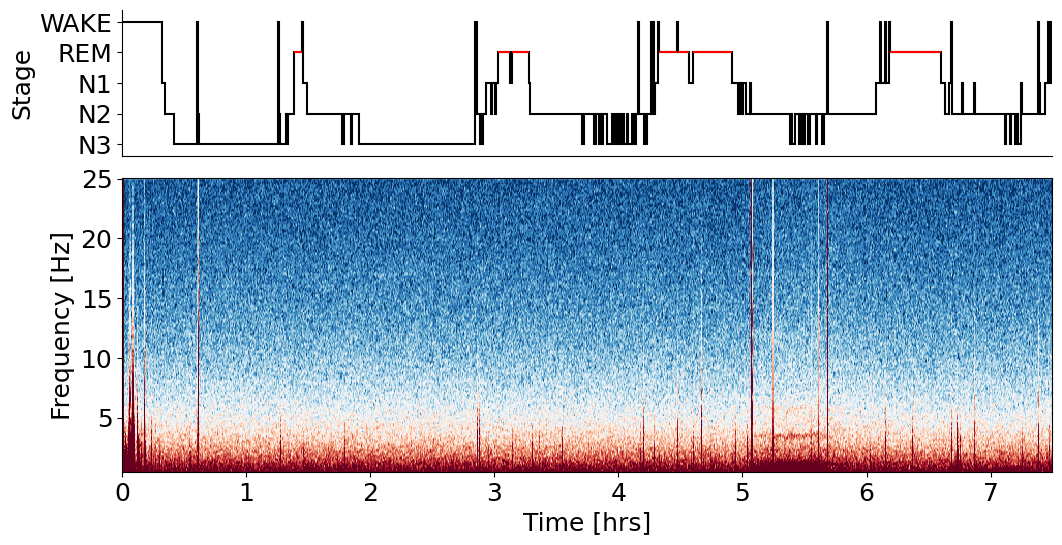

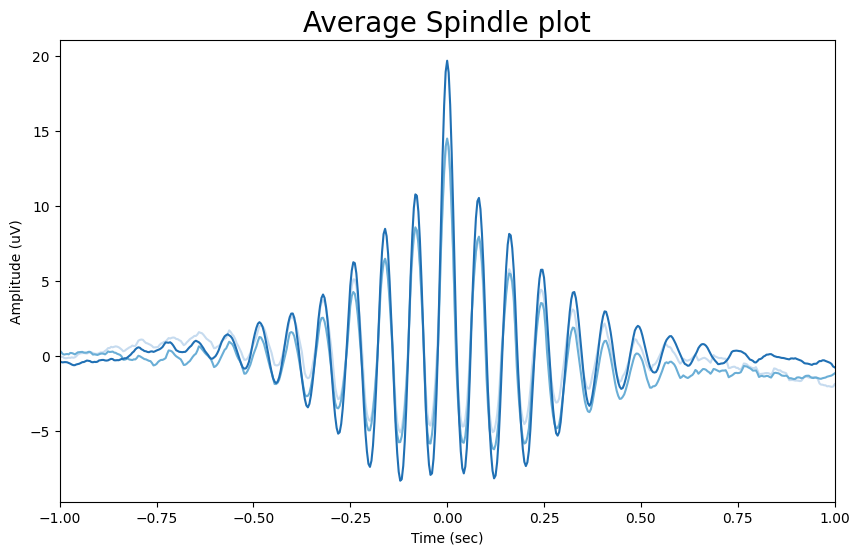

In [ ]:
sp.plot_average(ci=None, legend=False, palette='Blues', figsize=(10,6))

plt.title('Average Spindle plot', fontsize=20)
plt.show()

## Slow-waves

In [ ]:
sw = yasa.sw_detect(raw, hypno= hyp, include=['N2', 'N3'])

sw.summary()

04-Aug-26 09:49:12 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
04-Aug-26 09:49:13 | ERROR | Wrong data amplitude for IRED (trimmed STD = 0.003). Unit of data MUST be uV! Channel will be skipped.
04-Aug-26 09:49:13 | ERROR | Wrong data amplitude for RED (trimmed STD = 0.003). Unit of data MUST be uV! Channel will be skipped.
04-Aug-26 09:49:13 | ERROR | Wrong data amplitude for Snore (trimmed STD = 0.019). Unit of data MUST be uV! Channel will be skipped.
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.8s finished
04-Aug-26 09:49:15 | WARNING | No SW were found in channel Tilt3.


,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,Stage,Channel,IdxChannel
0,2213.007812,2213.289062,2213.851562,2214.027344,2214.183594,1.1758,-155.926002,14.890117,170.816119,277.201782,0.850485,2,EEG1,0
1,4597.085938,4597.429688,4597.781250,4598.105469,4598.425781,1.3398,-90.591140,51.665947,142.257088,257.681465,0.746380,3,EEG1,0
2,4600.226562,4600.546875,4601.085938,4601.515625,4601.871094,1.6445,-42.562093,43.141068,85.703160,78.955766,0.608088,3,EEG1,0
3,10306.449219,10306.703125,10306.917969,10307.175781,10307.582031,1.1328,-43.597894,49.421098,93.018992,202.928379,0.882768,2,EEG1,0
4,10307.582031,10308.019531,10308.289062,10308.554688,10308.851562,1.2695,-52.361461,52.379072,104.740533,194.268609,0.787712,2,EEG1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,24068.890625,24069.125000,24069.800781,24070.035156,24070.246094,1.3555,-74.444333,47.555231,121.999564,110.160400,0.737735,2,Tilt1,4
1051,10311.253906,10311.601562,10311.925781,10312.070312,10312.226562,0.9727,-80.441293,21.731870,102.173163,248.108085,1.028066,2,Tilt2,5
1052,10315.656250,10316.222656,10316.484375,10316.937500,10317.390625,1.7344,-43.511745,112.569111,156.080856,166.253832,0.576568,2,Tilt2,5
1053,21695.503906,21695.750000,21696.105469,21696.246094,21696.707031,1.2031,-172.944635,19.028158,191.972793,486.525567,0.831186,2,Tilt2,5


### Average Slow-wave plot

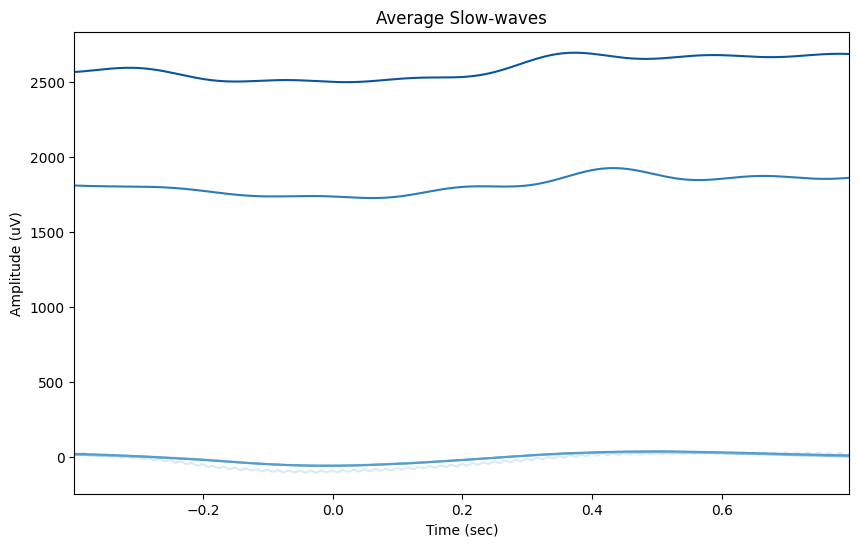

In [ ]:
sw.plot_average(ci=None, legend=False, palette='Blues',figsize=(10,6))

plt.title('Average Slow-waves')
plt.show()

##something appears off with the two higher bands (compared to the lower one that is more align with the expected frequency of the YASA demo documentation)

# Automatic Sleep Staging

In [ ]:
sls = yasa.SleepStaging(raw, eeg_name=)

SyntaxError: invalid syntax (49152563.py, line 1)

In [ ]:
import yasa
from sklearn.metrics import cohen_kappa_score
import pandas as pd

# Your ground-truth hypnogram (built earlier from primaryautostage / stage_final)
# 'hyp' should already exist as a yasa.Hypnogram object from your earlier mapping step
ground_truth_int = hyp.as_int().to_numpy()

results = []

for ch in ["EEG1", "EEG2", "EEG3", "EEG4"]:
    print(f"Running SleepStaging on {ch}...")
    
    sls = yasa.SleepStaging(raw, eeg_name=ch)
    hypno_pred = sls.predict()  # yasa.Hypnogram object
    
    pred_int = hypno_pred.as_int().to_numpy()
    
    # Align lengths in case of any epoch-count mismatch
    n = min(len(ground_truth_int), len(pred_int))
    
    kappa = cohen_kappa_score(ground_truth_int[:n], pred_int[:n])
    pct_agree = (ground_truth_int[:n] == pred_int[:n]).mean() * 100
    
    results.append({
        "channel": ch,
        "kappa": kappa,
        "pct_agreement": pct_agree,
    })

comparison_df = pd.DataFrame(results).sort_values("kappa", ascending=False)
print(comparison_df)

In [ ]:
import matplotlib.pyplot as plt

# Visually inspect EEG1 vs a "good" channel side by side
data_eeg1 = raw.get_data(picks='EEG1')[0] * 1e6
data_eeg4 = raw.get_data(picks='EEG4')[0] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(data_eeg1[:30000])  # first ~2 min at typical 250Hz
axes[0].set_title("EEG1")
axes[1].plot(data_eeg4[:30000])
axes[1].set_title("EEG4")
plt.tight_layout()
plt.show()

# Quick numeric diagnostics
print("EEG1 - std:", data_eeg1.std(), "| min/max:", data_eeg1.min(), data_eeg1.max())
print("EEG4 - std:", data_eeg4.std(), "| min/max:", data_eeg4.min(), data_eeg4.max())

In [ ]:
sls_eeg1 = yasa.SleepStaging(raw, eeg_name="EEG1")
pred_eeg1 = sls_eeg1.predict()
print(pred_eeg1.hypno.value_counts())

In [ ]:
### Are there actually 4 electrodes (EEG1 through EEG4) in the X8 profiler system? Or is this something to do with how the device approximates sleep stages and brain waveforms?

In [ ]:
sls_eeg4 = yasa.SleepStaging(raw, eeg_name="EEG4")
pred_eeg4 = sls_eeg4.predict()
print(pred_eeg4.hypno.value_counts())